# 02_Statistical Analysis
# Japan Birth Statistics 1899–2023
> quantify the strength of Japan's demographic decline through

> correlation, hypothesis testing, and statistical profiling.

In [2]:
# Data Import setup 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')
plt.rcParams.update({
     'figure.facecolor': '#0d0d1a',
     'axes.facecolor':   '#0d0d1a',
     'axes.edgecolor':   '#2a2a40',
     'axes.titlecolor':  '#ffffff',
     'axes.labelcolor':  '#d0d0e0',
     'xtick.color':      '#a0a0b8',
     'ytick.color':      '#a0a0b8',
     'text.color':       '#d0d0e0',
     'grid.color':       '#1a1a2e',
     'grid.linewidth':   0.8,
     'font.family':      'DejaVu Sans',
     'axes.titlesize':   14,
     'axes.labelsize':   11,
     'legend.fontsize':  9,
     'legend.framealpha': 0.15,
     'legend.edgecolor': '#333355',
})

C = dict(
     red    = '#e94560',
     teal   = '#00b4d8',
     gold   = '#f5a623',
     purple = '#7b2ff7',
     green  = '#06d6a0',
     pink   = '#f72585',
     blue   = '#4361ee',
     orange = '#ff9f1c',
     white  = '#e8e8f0',
)



In [3]:
# Load the data 

df = pd.read_csv("../data/backup_japan.csv", index_col=0)
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
df = df.sort_values('year').reset_index(drop=True)
# Feature engineering
def label_era(year):
     if year < 1945:   return 'Pre-War (1899–1944)'
     elif year < 1955: return 'Post-War Boom (1945–1954)'
     elif year < 1975: return 'High Growth (1955–1974)'
     elif year < 1990: return 'Bubble Era (1975–1989)'
     elif year < 2010: return 'Lost Decades (1990–2009)'
     else:             return 'Modern Crisis (2010–2023)'

df['era']        = df['year'].apply(label_era)
df['decade']     = (df['year'] // 10) * 10
df['yoy_change'] = df['total_births'].diff()
df['yoy_pct']    = df['total_births'].pct_change() * 100
# df.columns
print(f"{df.shape}")

(122, 11)


In [4]:
# Convert key columns to NumPy arrays
births  = df['total_births'].to_numpy()
years   = df['year'].to_numpy()
male    = df['male_births'].to_numpy()
female  = df['female_births'].to_numpy()
cbr     = df['crude_birth_rate'].to_numpy()
sex_rat = df['sex_ratio_at_birth'].to_numpy()
tfr     = df['total_fertility_rate'].dropna().to_numpy()

print(f"   NumPy arrays created")
print(f"   births  : {births.shape}")
print(f"   years   : {years.shape}")
print(f"   tfr     : {tfr.shape}  (45 nulls excluded)")

   NumPy arrays created
   births  : (122,)
   years   : (122,)
   tfr     : (77,)  (45 nulls excluded)


In [5]:
print("  NUMPY STATISTICAL SUMMARY — TOTAL BIRTHS")
print(f"  Mean              : {np.mean(births):>12,.0f}")
print(f"  Median            : {np.median(births):>12,.0f}")
print(f"  Std Deviation     : {np.std(births):>12,.0f}")
print(f"  Variance          : {np.var(births):>12,.0f}")
print(f"  Min               : {np.min(births):>12,.0f}  ({years[np.argmin(births)]})")
print(f"  Max               : {np.max(births):>12,.0f}  ({years[np.argmax(births)]})")
print(f"  Range             : {np.ptp(births):>12,.0f}")
print(f"  Skewness          : {stats.skew(births):>12.4f}")
print(f"  Kurtosis          : {stats.kurtosis(births):>12.4f}")
print("=" * 55)

  NUMPY STATISTICAL SUMMARY — TOTAL BIRTHS
  Mean              :    1,619,319
  Median            :    1,656,495
  Std Deviation     :      437,482
  Variance          : 191,390,764,931
  Min               :      727,288  (2023)
  Max               :    2,696,638  (1949)
  Range             :    1,969,350
  Skewness          :       0.0464
  Kurtosis          :      -0.6414


## This number tell us 
- Mean > Median — the distribution is right-skewed,
  pulled up by the high birth years of the 1940s–1970s
- Std of ~400K — births vary enormously across 124 years
- Positive skewness- confirms most years cluster in the
  lower range with a long tail toward the high birth years

# Correlation Analysis 

In [6]:
df.columns

Index(['year', 'total_births', 'male_births', 'female_births',
       'crude_birth_rate', 'sex_ratio_at_birth', 'total_fertility_rate', 'era',
       'decade', 'yoy_change', 'yoy_pct'],
      dtype='object')

In [8]:
# Numpy correaliton 

print("Correaltion analysis - yaer vs all columns ")

columns = {
          'total_births' : births,
          'male_births' : male,
          'female_births' : female,
          'crude_birth_rate' : cbr,
          'sex_ratio_at_birth' : sex_rat,
}

for name, arr in columns.items():
     corr = np.corrcoef(years,arr)[0,1]
     
          # Strength label
     if abs(corr) >= 0.9:   strength = 'Very Strong'
     elif abs(corr) >= 0.7: strength = 'Strong'
     elif abs(corr) >= 0.5: strength = 'Moderate'
     else:                  strength = 'Weak'
     
     direction = 'Negative ↓' if corr < 0 else 'Positive ↑'
    
     print(f"  {name:<22} r = {corr:>7.4f}  {direction}  {strength}")

Correaltion analysis - yaer vs all columns 
  total_births           r = -0.6650  Negative ↓  Moderate
  male_births            r = -0.6597  Negative ↓  Moderate
  female_births          r = -0.6705  Negative ↓  Moderate
  crude_birth_rate       r = -0.9576  Negative ↓  Very Strong
  sex_ratio_at_birth     r =  0.3902  Positive ↑  Weak


What These Results Tell Us

- **Crude Birth Rate (r = −0.96)** — the strongest relationship.
  Almost perfectly negative — as years go by, birth rate falls consistently

- **Total Births (r = −0.67)** — Moderate, not Very Strong.
  This is because of the two baby booms (1947–1949, 1971–1974)
  which created temporary spikes that break the straight-line trend

- **Male & Female Births (r ≈ −0.66)** — almost identical to total births,
  which makes sense since they move together

- **Sex Ratio (r = +0.39)** — weak positive, barely changes over 124 years.
  Biology is consistent even as society changes dramatically

>  The Crude Birth Rate is a better indicator of decline than raw birth
> counts because it accounts for population size changes over time

# Correaltion Heatmap

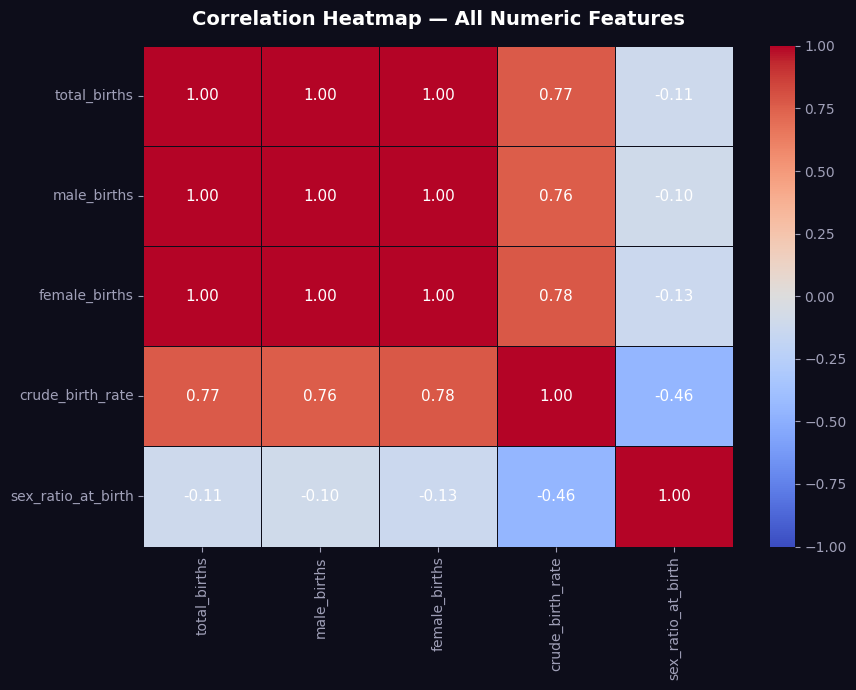

In [11]:
# Build correlation matrix using NumPy
corr_cols = ['total_births', 'male_births', 'female_births',
               'crude_birth_rate', 'sex_ratio_at_birth']

corr_df   = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(corr_df,
               annot=True, fmt='.2f',
               cmap='coolwarm',
               center=0, vmin=-1, vmax=1,
               linewidths=0.5,
               linecolor='#0d0d1a',
               ax=ax,
               annot_kws={'size': 11, 'color': 'white'})

ax.set_title("Correlation Heatmap — All Numeric Features",
               fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/10_correlation_heatmap.png', dpi=150,
               bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

###  Reading the Heatmap

- **Dark red = strong positive correlation** — move together
- **Dark blue = strong negative correlation** — move opposite
- **Male & Female births vs Total births** should be near 1.0 — expected
- **Sex ratio** should show weak correlation — it barely changes over time

# Decade Wise Analysis 

In [12]:
era_order = [
    'Pre-War (1899–1944)',
    'Post-War Boom (1945–1954)',
    'High Growth (1955–1974)',
    'Bubble Era (1975–1989)',
    'Lost Decades (1990–2009)',
    'Modern Crisis (2010–2023)',
]

decade_stats = df.groupby('decade').agg(
    Years        = ('year', 'count'),
    Avg_Births   = ('total_births', 'mean'),
    Max_Births   = ('total_births', 'max'),
    Min_Births   = ('total_births', 'min'),
    Avg_CBR      = ('crude_birth_rate', 'mean'),
    Std_Births   = ('total_births', 'std'),
).round(0)

decade_stats['Avg_Births'] = decade_stats['Avg_Births'].apply(lambda x: f'{x:,.0f}')
decade_stats['Max_Births'] = decade_stats['Max_Births'].apply(lambda x: f'{x:,.0f}')
decade_stats['Min_Births'] = decade_stats['Min_Births'].apply(lambda x: f'{x:,.0f}')
decade_stats['Std_Births'] = decade_stats['Std_Births'].apply(lambda x: f'{x:,.0f}')

print("=" * 75)
print("  DECADE-WISE STATISTICAL SUMMARY")
print("=" * 75)
print(decade_stats.to_string())
print("=" * 75)

  DECADE-WISE STATISTICAL SUMMARY
        Years Avg_Births Max_Births Min_Births  Avg_CBR Std_Births
decade                                                            
1890        1  1,386,981  1,386,981  1,386,981     32.0        nan
1900       10  1,518,135  1,693,850  1,394,295     33.0    104,030
1910       10  1,775,142  1,812,413  1,712,857     34.0     34,321
1920       10  2,049,168  2,135,852  1,969,314     34.0     53,510
1930       10  2,083,896  2,190,704  1,901,573     31.0    100,935
1940        7  2,419,628  2,696,638  2,115,867     32.0    254,049
1950       10  1,836,022  2,337,507  1,566,713     21.0    250,934
1960       10  1,707,228  1,935,647  1,360,974     17.0    176,514
1970       10  1,893,625  2,091,983  1,642,580     17.0    153,612
1980       10  1,434,219  1,576,889  1,246,802     12.0    107,768
1990       10  1,204,653  1,238,328  1,177,669     10.0     19,047
2000       10  1,115,561  1,190,547  1,062,530      9.0     43,308
2010       10    990,552  1,

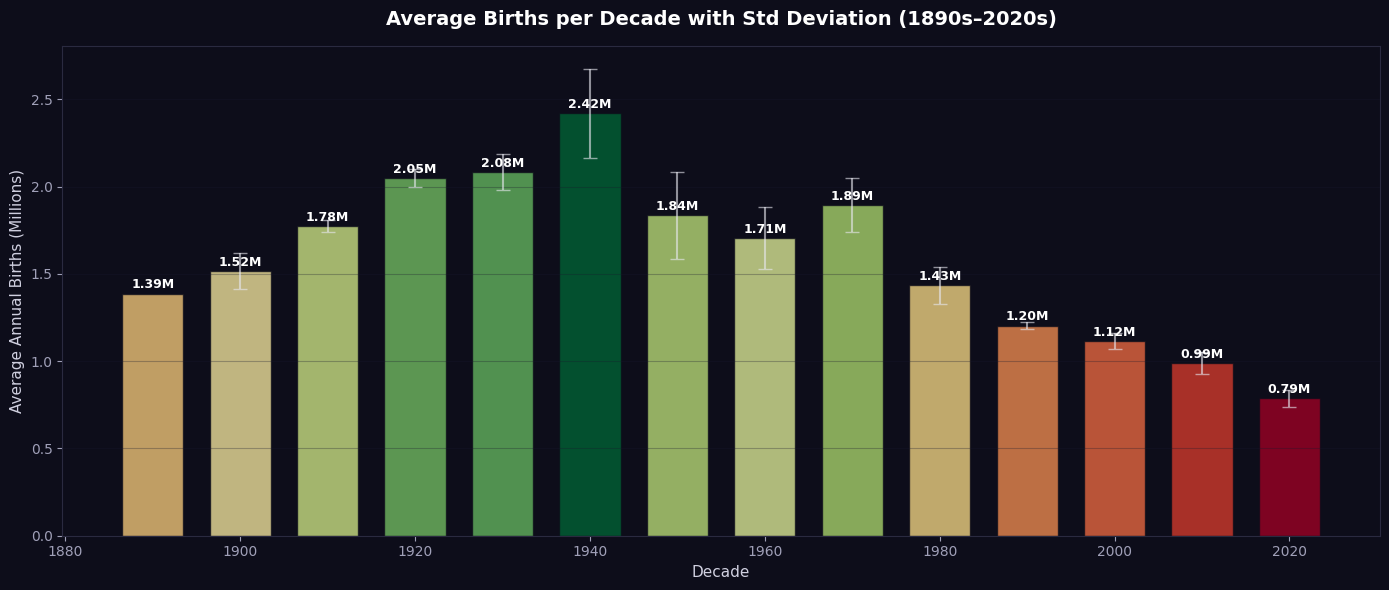

In [14]:
decade_avg = df.groupby('decade')['total_births'].mean() / 1e6
decade_std = df.groupby('decade')['total_births'].std()  / 1e6

fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(decade_avg.index, decade_avg.values,
              width=7, color=C['teal'],
              alpha=0.75, edgecolor='#0d0d1a')

# Colour bars by value — darker = lower births
colours = plt.cm.RdYlGn(
    (decade_avg.values - decade_avg.min()) /
    (decade_avg.max()  - decade_avg.min())
)
for bar, col in zip(bars, colours):
    bar.set_facecolor(col)

# Error bars showing std deviation
ax.errorbar(decade_avg.index, decade_avg.values,
            yerr=decade_std.values,
            fmt='none', color=C['white'],
            capsize=5, linewidth=1.5, alpha=0.6)

# Value labels
for bar, val in zip(bars, decade_avg.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            f'{val:.2f}M',
            ha='center', fontsize=9,
            color='white', fontweight='bold')

ax.set_title("Average Births per Decade with Std Deviation (1890s–2020s)",
             fontweight='bold', pad=15)
ax.set_xlabel("Decade")
ax.set_ylabel("Average Annual Births (Millions)")
# ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/11_decade_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0d0d1a')
plt.show()